In [7]:
# Price Elasticity Model

# This model estimates how demand changes with price using log-log regression.

Price Elasticity: -0.1742256218451021


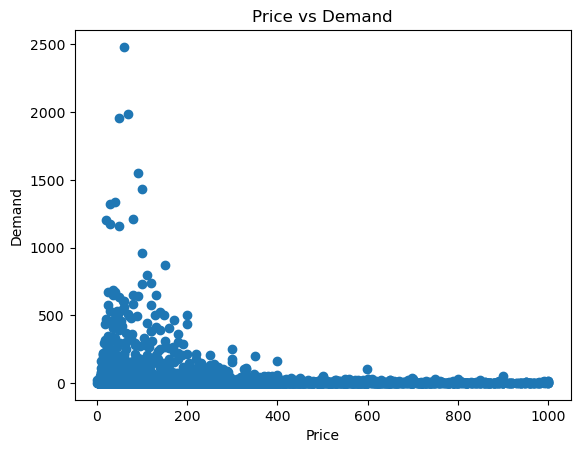

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('C:\\Users\\harsh\\Desktop\\pricing_project\\olist_order_items_dataset.csv')

# Create demand proxy
df['demand'] = 1

# Group by price
grouped = df.groupby('price').agg({'demand': 'sum'}).reset_index()
grouped = grouped[grouped['price'] < 1000]

# Remove zero values (important for log)
grouped = grouped[(grouped['price'] > 0) & (grouped['demand'] > 0)]

# Log transformation
grouped['log_price'] = np.log(grouped['price'])
grouped['log_demand'] = np.log(grouped['demand'])

# Model
X = grouped[['log_price']]
y = grouped['log_demand']

model = LinearRegression()
model.fit(X, y)

elasticity = model.coef_[0]

print("Price Elasticity:", elasticity)

# Plot
plt.scatter(grouped['price'], grouped['demand'])
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")
plt.show()

In [21]:
# Discount simulation
discounts = [0, 0.1, 0.2, 0.3]

results = []

for d in discounts:
    grouped['new_price'] = grouped['price'] * (1 - d)
    
    # Demand using elasticity
    grouped['predicted_demand'] = grouped['demand'] * (grouped['new_price'] / grouped['price']) ** elasticity
    
    grouped['revenue'] = grouped['new_price'] * grouped['predicted_demand']
    
    total_revenue = grouped['revenue'].sum()
    
    results.append((d, total_revenue))

# Best discount
best = max(results, key=lambda x: x[1])

print("Best Discount:", best[0])
print("Max Revenue:", best[1])

Best Discount: 0
Max Revenue: 12248529.579999998


In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load datasets
items = pd.read_csv('C:\\Users\\harsh\\Desktop\\pricing_project\\olist_order_items_dataset.csv')
products = pd.read_csv('C:\\Users\\harsh\\Desktop\\pricing_project\\olist_products_dataset.csv')

# Merge
df = items.merge(products[['product_id','product_category_name']], on='product_id')

df['demand'] = 1

results = []

categories = df['product_category_name'].dropna().unique()

for cat in categories[:10]:  # limit for speed
    temp = df[df['product_category_name'] == cat]
    
    grouped = temp.groupby('price').agg({'demand':'sum'}).reset_index()
    grouped = grouped[(grouped['price'] > 0) & (grouped['demand'] > 0)]
    
    if len(grouped) < 5:
        continue
    
    grouped['log_price'] = np.log(grouped['price'])
    grouped['log_demand'] = np.log(grouped['demand'])
    
    X = grouped[['log_price']]
    y = grouped['log_demand']
    
    model = LinearRegression().fit(X,y)
    
    elasticity = model.coef_[0]
    
    results.append((cat, elasticity))

elasticity_df = pd.DataFrame(results, columns=['category','elasticity'])

print(elasticity_df.sort_values(by='elasticity'))

                      category  elasticity
2             moveis_decoracao   -0.318545
9  fashion_bolsas_e_acessorios   -0.296408
6                    telefonia   -0.263669
8              livros_tecnicos   -0.253664
5        utilidades_domesticas   -0.188331
7                 beleza_saude   -0.185369
3                   perfumaria   -0.140102
0                   cool_stuff   -0.136185
4           ferramentas_jardim   -0.128842
1                     pet_shop   -0.106995


In [29]:
# Add cost assumption
df['cost'] = df['price'] * 0.7   # 30% margin

discounts = [0, 0.1, 0.2, 0.3]

results = []

for d in discounts:
    df['new_price'] = df['price'] * (1 - d)
    
    df['predicted_demand'] = df['demand'] * (df['new_price'] / df['price']) ** (-0.17)
    
    df['profit'] = (df['new_price'] - df['cost']) * df['predicted_demand']
    
    total_profit = df['profit'].sum()
    
    results.append((d, total_profit))

best = max(results, key=lambda x: x[1])

print("Best Discount:", best[0])
print("Max Profit:", round(best[1]))

Best Discount: 0
Max Profit: 4077493
